# Mathematical Model Implementation using Google OR-Tools
## 1. Environment Setup and Data Ingestion

In [1]:
import pandas as pd
import numpy as np
from ortools.linear_solver import pywraplp
from IPython.display import display
import matplotlib.pyplot as plt

print("Ingesting Niagara Falls geographical datasets.")
df_demand = pd.read_csv('niagara_demand_nodes.csv')
df_candidates = pd.read_csv('niagara_candidate_stations.csv')
df_coverage = pd.read_csv('niagara_coverage_matrix.csv')

# Let's quickly double-check our row counts to ensure data integrity
print(f"Successfully loaded {len(df_demand)} demand nodes and {len(df_candidates)} station candidates.")

Ingesting Niagara Falls geographical datasets.
Successfully loaded 28 demand nodes and 12 station candidates.


## 2. Parameter and Set Definitions

In [2]:
# Defining temporal and spatial indices
periods = ['Peak', 'OffPeak']
num_nodes = len(df_demand)
num_candidates = len(df_candidates)

# Financial parameters for energy sourcing ($/kWh)
tariff_grid = {'Peak': 0.15, 'OffPeak': 0.08} 
cost_solar = 0.05
cost_wind = 0.06

# Operational assumption: an average EV requires roughly 50 kWh per charging session
kwh_per_ev = 50.0 

# Transforming our coverage dataframe into a fast-lookup dictionary for the constraints
r = {}
for _, row in df_coverage.iterrows():
    r[int(row['Node_ID']), int(row['Candidate_ID'])] = int(row['r_ij_Covered'])

print("Sets, costs, and operational constants have been successfully initialized.")

Sets, costs, and operational constants have been successfully initialized.


## 3. Solver and Decision Variables Initialization

In [3]:
# Creating our mathematical programming solver instance using SCIP
solver = pywraplp.Solver.CreateSolver('SCIP')
if not solver:
    print("Error: Could not trigger the SCIP solver environment.")

# A. Binary Variables: Station location choice (x_j)
x = {}
for j in range(num_candidates):
    x[j] = solver.IntVar(0, 1, f'x_{j}')

# B. Binary Variables: Demand routing allocation (y_ij)
y = {}
for i in range(num_nodes):
    for j in range(num_candidates):
        y[i, j] = solver.IntVar(0, 1, f'y_{i}_{j}')

# C. Continuous Variables: Multi-period energy dispatch (e_grid, e_solar, e_wind)
e_grid, e_solar, e_wind = {}, {}, {}
for j in range(num_candidates):
    for t in periods:
        e_grid[j, t] = solver.NumVar(0, solver.infinity(), f'e_grid_{j}_{t}')
        e_solar[j, t] = solver.NumVar(0, solver.infinity(), f'e_solar_{j}_{t}')
        e_wind[j, t] = solver.NumVar(0, solver.infinity(), f'e_wind_{j}_{t}')

# D. Continuous Variables: Unmet priority penalties tracking (u_i)
u = {}
for i in range(num_nodes):
    u[i] = solver.NumVar(0, solver.infinity(), f'u_{i}')

print(f"Declared {solver.NumVariables()} mathematical variables in the solver environment.")

Declared 448 mathematical variables in the solver environment.


## 4. Constraint Formulation

In [4]:
# Constraint Group 4.1: Spatial Coverage Logic
for i in range(num_nodes):
    for j in range(num_candidates):
        solver.Add(y[i, j] <= r[i, j] * x[j])

# Constraint Group 4.2: Unmet Demand Calculations
for i in range(num_nodes):
    served = solver.Sum([y[i, j] for j in range(num_candidates)])
    total_demand = df_demand.loc[i, 'Demand_Peak'] + df_demand.loc[i, 'Demand_OffPeak']
    solver.Add(u[i] >= total_demand * (1 - served))

# Constraint Group 4.3: Dynamic Energy Balance and Resource Limits
# NEW: We define how many hours each period lasts to convert Power (kW) to Energy (kWh)
hours = {'Peak': 14, 'OffPeak': 10}

for j in range(num_candidates):
    for t in periods:
        demand_col = 'Demand_Peak' if t == 'Peak' else 'Demand_OffPeak'
        energy_needed = solver.Sum([y[i, j] * df_demand.loc[i, demand_col] * kwh_per_ev for i in range(num_nodes)])
        solver.Add(energy_needed <= e_grid[j, t] + e_solar[j, t] + e_wind[j, t])
        
        # Convert kW to kWh capacities based on period duration
        max_grid_kwh = df_candidates.loc[j, 'Grid_Max_kW'] * hours[t]
        max_solar_kwh = (df_candidates.loc[j, 'Solar_Max_kW'] * hours[t]) if t == 'Peak' else 0
        max_wind_kwh = df_candidates.loc[j, 'Wind_Max_kW'] * hours[t]
        
        solver.Add(e_grid[j, t] <= max_grid_kwh * x[j])
        solver.Add(e_solar[j, t] <= max_solar_kwh * x[j])
        solver.Add(e_wind[j, t] <= max_wind_kwh * x[j])

# Constraint Group 4.4: Strategic Capital Budget Constraint
budget = 350000
solver.Add(solver.Sum([x[j] * df_candidates.loc[j, 'Setup_Cost'] for j in range(num_candidates)]) <= budget)

print(f"Successfully generated and linked {solver.NumConstraints()} constraints to the model.")

Successfully generated and linked 461 constraints to the model.


## 5. Objective Function and Model Execution

In [5]:
# 5.1 Compiling the structural objective components
infrastructure_cost = solver.Sum([x[j] * df_candidates.loc[j, 'Setup_Cost'] for j in range(num_candidates)])

energy_cost_components = []
for j in range(num_candidates):
    for t in periods:
        energy_cost_components.append(e_grid[j, t] * tariff_grid[t] + e_solar[j, t] * cost_solar + e_wind[j, t] * cost_wind)
energy_cost = solver.Sum(energy_cost_components)

# FIX: Massive penalty multiplier (Big-M) to force the solver to prioritize coverage over saving budget
penalty_rate = 100000 
priority_penalty = solver.Sum([u[i] * df_demand.loc[i, 'Priority_Weight_wi'] * penalty_rate for i in range(num_nodes)])

solver.Minimize(infrastructure_cost + energy_cost + priority_penalty)

# 5.2 Launching the optimization sequence
print("Kicking off the solver... Processing the Branch-and-Bound tree.")
solver.SetTimeLimit(60000) 
status = solver.Solve()
print("Optimization routine completed.")

Kicking off the solver... Processing the Branch-and-Bound tree.
Optimization routine completed.


## 6. Post-Processing and Key Performance Indicators (KPIs)

In [6]:
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print("=" * 50)
    print("             OPTIMIZATION REPORT                 ")
    print("=" * 50)
    print(f"Total Combined Objective Cost : ${solver.Objective().Value():,.2f}")
    
    # Identify which stations were selected for construction
    built_stations = [j for j in range(num_candidates) if x[j].solution_value() > 0.5]
    print(f"Optimal Station Allocations   : {len(built_stations)} built stations")
    print(f"Selected Candidate IDs        : {built_stations}")
    
    # Financial breakdown
    total_setup = sum([df_candidates.loc[j, 'Setup_Cost'] for j in built_stations])
    print(f"Infrastructure Capital Spent  : ${total_setup:,.2f} / ${budget:,.2f} Budget")
    print(f"Total Operational Energy Costs: ${energy_cost.solution_value():,.2f}")
    
    # Operational breakdown
    unmet_cars = sum([u[i].solution_value() for i in range(num_nodes)])
    print(f"Unmapped/Unmet Traffic Demand : {unmet_cars:.1f} cars remaining")
    print("=" * 50)
    
    # Let's save our results into an output dataframe for easy verification
    stations_output = []
    for j in range(num_candidates):
        stations_output.append({
            'Candidate_ID': j,
            'Is_Built': 1 if x[j].solution_value() > 0.5 else 0,
            'Setup_Cost': df_candidates.loc[j, 'Setup_Cost'],
            'Peak_Grid_kW': e_grid[j, 'Peak'].solution_value(),
            'Peak_Solar_kW': e_solar[j, 'Peak'].solution_value(),
            'OffPeak_Wind_kW': e_wind[j, 'OffPeak'].solution_value()
        })
    df_results = pd.DataFrame(stations_output)
    df_results.to_csv('niagara_solver_outputs.csv', index=False)
    print("Saved final model execution parameters to 'niagara_solver_outputs.csv'.")
    
else:
    print("Bummer. The solver could not find a mathematically feasible state within the boundaries.")

             OPTIMIZATION REPORT                 
Total Combined Objective Cost : $284,596.48
Optimal Station Allocations   : 6 built stations
Selected Candidate IDs        : [1, 3, 5, 7, 8, 10]
Infrastructure Capital Spent  : $280,724.00 / $350,000.00 Budget
Total Operational Energy Costs: $3,872.48
Unmapped/Unmet Traffic Demand : 0.0 cars remaining
Saved final model execution parameters to 'niagara_solver_outputs.csv'.


## 7. Baseline Model Execution (For Comparison)

In [7]:
print("=" * 50)
print("       INITIATING BASELINE MODEL COMPARISON       ")
print("=" * 50)

# 7.1 Initialize a fresh solver instance for the baseline
solver_base = pywraplp.Solver.CreateSolver('SCIP')

# 7.2 Decision Variables (Only x_j and y_ij are needed)
x_base = {}
for j in range(num_candidates):
    x_base[j] = solver_base.IntVar(0, 1, f'x_base_{j}')

y_base = {}
for i in range(num_nodes):
    for j in range(num_candidates):
        y_base[i, j] = solver_base.IntVar(0, 1, f'y_base_{i}_{j}')

u_base = {}
for i in range(num_nodes):
    u_base[i] = solver_base.NumVar(0, solver_base.infinity(), f'u_base_{i}')

# 7.3 Constraints (Simplified)
# Coverage Logic
for i in range(num_nodes):
    for j in range(num_candidates):
        solver_base.Add(y_base[i, j] <= r[i, j] * x_base[j])

# Unmet Demand (No peak/off-peak distinction, just total daily cars)
for i in range(num_nodes):
    served_base = solver_base.Sum([y_base[i, j] for j in range(num_candidates)])
    total_demand_base = df_demand.loc[i, 'Demand_Peak'] + df_demand.loc[i, 'Demand_OffPeak']
    solver_base.Add(u_base[i] >= total_demand_base * (1 - served_base))

# Budget Constraint
solver_base.Add(solver_base.Sum([x_base[j] * df_candidates.loc[j, 'Setup_Cost'] for j in range(num_candidates)]) <= budget)

# 7.4 Objective Function (Minimize Setup Cost + Standard Flat Penalty)
# Note: In the base model, all nodes are treated equally (Priority Weight is ignored).
# We use a standard penalty to force coverage.
standard_penalty = 100000 
base_infrastructure_cost = solver_base.Sum([x_base[j] * df_candidates.loc[j, 'Setup_Cost'] for j in range(num_candidates)])
base_penalty_cost = solver_base.Sum([u_base[i] * standard_penalty for i in range(num_nodes)])

solver_base.Minimize(base_infrastructure_cost + base_penalty_cost)

# 7.5 Solve the Baseline Model
solver_base.SetTimeLimit(60000)
status_base = solver_base.Solve()

# 7.6 Print Baseline Results
if status_base == pywraplp.Solver.OPTIMAL or status_base == pywraplp.Solver.FEASIBLE:
    print(f"Baseline Total Objective Cost: ${solver_base.Objective().Value():,.2f}")
    
    built_stations_base = [j for j in range(num_candidates) if x_base[j].solution_value() > 0.5]
    print(f"Baseline Station Allocations : {len(built_stations_base)} built stations")
    print(f"Baseline Selected IDs        : {built_stations_base}")
    
    total_setup_base = sum([df_candidates.loc[j, 'Setup_Cost'] for j in built_stations_base])
    print(f"Baseline Capital Spent       : ${total_setup_base:,.2f} / ${budget:,.2f} Budget")
    
    unmet_cars_base = sum([u_base[i].solution_value() for i in range(num_nodes)])
    print(f"Baseline Unmet Traffic Demand: {unmet_cars_base:.1f} cars remaining")
    print("=" * 50)
    print("Ready to compare Base vs. Extended")
else:
    print("Could not solve the baseline model.")

       INITIATING BASELINE MODEL COMPARISON       
Baseline Total Objective Cost: $131,175.00
Baseline Station Allocations : 3 built stations
Baseline Selected IDs        : [5, 8, 10]
Baseline Capital Spent       : $131,175.00 / $350,000.00 Budget
Baseline Unmet Traffic Demand: 0.0 cars remaining
Ready to compare Base vs. Extended


## 8. Executive Summary: Baseline vs. Extended Model Comparison

In [8]:
# 1. Gather Extended Model Data
extended_built_count = len(built_stations)
extended_built_ids = ", ".join(map(str, built_stations))
extended_setup_cost = total_setup
extended_unmet = unmet_cars
extended_obj = solver.Objective().Value()

# 2. Gather Baseline Model Data
base_built_count = len(built_stations_base)
base_built_ids = ", ".join(map(str, built_stations_base))
base_setup_cost = total_setup_base
base_unmet = unmet_cars_base
base_obj = solver_base.Objective().Value()

# 3. Construct the Comparison Dictionary
comparison_data = {
    "Key Performance Indicator": [
        "Stations Built (Count)",
        "Selected Station IDs",
        "Capital Infrastructure Spent",
        "Unmet Traffic Demand (Cars)",
        "Total Objective Cost (Math Score)"
    ],
    "Baseline Model (Traditional)": [
        base_built_count,
        base_built_ids,
        f"${base_setup_cost:,.2f}",
        f"{base_unmet:.1f}",
        f"${base_obj:,.2f}"
    ],
    "Extended Model (Our Approach)": [
        extended_built_count,
        extended_built_ids,
        f"${extended_setup_cost:,.2f}",
        f"{extended_unmet:.1f}",
        f"${extended_obj:,.2f}"
    ]
}

# 4. Create and Display DataFrame
df_comparison = pd.DataFrame(comparison_data)

print("=" * 80)
print("              FINAL EXECUTIVE COMPARISON: BASELINE VS EXTENDED")
print("=" * 80)

# display() renders a beautifully formatted table in Jupyter Notebooks
display(df_comparison)

# 5. Export for the Final Report
df_comparison.to_csv('niagara_models_comparison.csv', index=False)
print("\nSuccess: The comparison table has been exported as 'niagara_models_comparison.csv'.")

              FINAL EXECUTIVE COMPARISON: BASELINE VS EXTENDED


,Key Performance Indicator,Baseline Model (Traditional),Extended Model (Our Approach)
0,Stations Built (Count),3,6
1,Selected Station IDs,"5, 8, 10","1, 3, 5, 7, 8, 10"
2,Capital Infrastructure Spent,"$131,175.00","$280,724.00"
3,Unmet Traffic Demand (Cars),0.0,0.0
4,Total Objective Cost (Math Score),"$131,175.00","$284,596.48"



Success: The comparison table has been exported as 'niagara_models_comparison.csv'.


## 9. Sensitivity Analysis: What-If Scenarios

  SCENARIO A: Sensitivity to Capital Budget Constraint
  $ 350,000 → 6 stations | Unmet: 0 cars | ΔEnergy: +0.0%
  $ 300,000 → 6 stations | Unmet: 0 cars | ΔEnergy: +0.0%
  $ 250,000 → 5 stations | Unmet: 55 cars | ΔEnergy: -2.9%
  $ 200,000 → 4 stations | Unmet: 161 cars | ΔEnergy: -18.9%
  $ 150,000 → 3 stations | Unmet: 314 cars | ΔEnergy: -37.9%
  $ 100,000 → 2 stations | Unmet: 465 cars | ΔEnergy: -58.0%

--- Table 2: Scenario A — Budget Sensitivity Results ---


,Budget ($),Stations Built,CAPEX Spent ($),Energy Cost ($),Grid Draw (kWh),Unmet Demand (cars),Energy Cost Δ vs Base
0,"$350,000",6,"$280,724","$3,872.48","24,442",0,+0.0%
1,"$300,000",6,"$280,724","$3,872.48","24,442",0,+0.0%
2,"$250,000",5,"$248,625","$3,759.23","24,436",55,-2.9%
3,"$200,000",4,"$193,846","$3,140.37","20,292",161,-18.9%
4,"$150,000",3,"$143,261","$2,405.42","15,584",314,-37.9%
5,"$100,000",2,"$90,321","$1,624.57","10,388",465,-58.0%


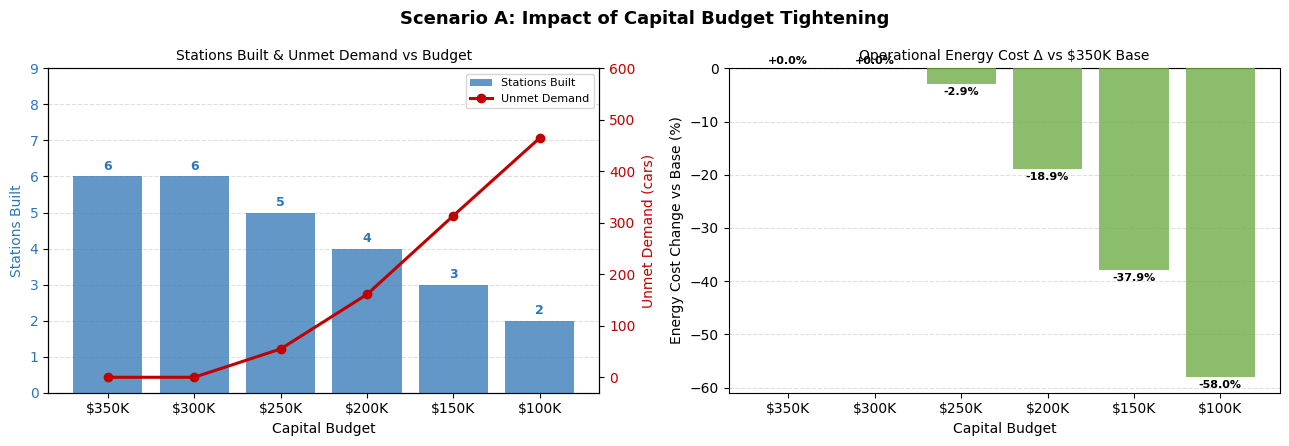

Figure 4 saved: scenario_A_sensitivity.png

  SCENARIO B: Sensitivity to Unmet Demand Penalty Rate
  $     500/car → 5 stations | Unmet: 57 | Pay penalty — skip stations
  $   1,000/car → 6 stations | Unmet: 0 | Full coverage achieved
  $   5,000/car → 6 stations | Unmet: 0 | Full coverage achieved
  $  10,000/car → 6 stations | Unmet: 0 | Full coverage achieved
  $  50,000/car → 6 stations | Unmet: 0 | Full coverage achieved
  $ 100,000/car → 6 stations | Unmet: 0 | Full coverage achieved
  $ 150,000/car → 6 stations | Unmet: 0 | Full coverage achieved

--- Table 3: Scenario B — Penalty Rate Sensitivity Results ---


,Penalty Rate ($/car),Stations Built,CAPEX Spent ($),Energy Cost ($),Unmet Demand (cars),Objective Value ($),Model Behavior
0,$500,5,"$236,539","$3,733.95",57,"$268,772.95",Pay penalty — skip stations
1,"$1,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved
2,"$5,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved
3,"$10,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved
4,"$50,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved
5,"$100,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved
6,"$150,000",6,"$280,724","$3,872.48",0,"$284,596.48",Full coverage achieved


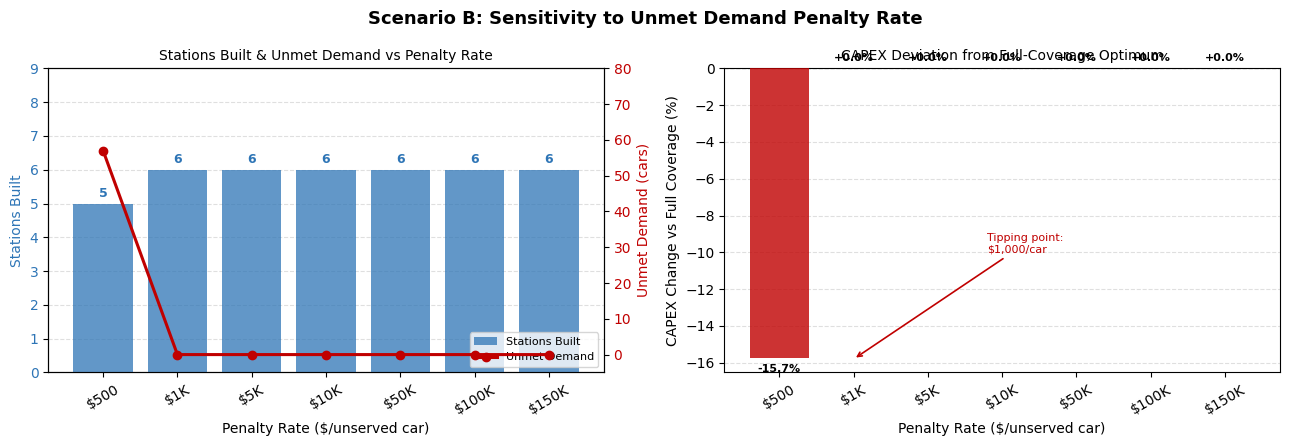

Figure 5 saved: scenario_B_sensitivity.png

  KEY FINDINGS — SENSITIVITY ANALYSIS SUMMARY


In [9]:
# ─ Sensitivity Analysis Helper 
# Uses the same parameters already defined in cells above:
# r, df_demand, df_candidates, num_nodes, num_candidates,
# periods, hours, tariff_grid, cost_solar, cost_wind, kwh_per_ev, budget

BASE_ENERGY_COST = energy_cost.solution_value()  # From the Extended Model (Section 5)

def solve_sensitivity(budget_val, penalty_val):
    """Re-solves the Extended MILP for a given budget and penalty rate."""
    s = pywraplp.Solver.CreateSolver('SCIP')

    xs = {j:     s.IntVar(0, 1, f'xs_{j}')                     for j in range(num_candidates)}
    ys = {(i,j): s.IntVar(0, 1, f'ys_{i}_{j}')                 for i in range(num_nodes) for j in range(num_candidates)}
    eg = {(j,t): s.NumVar(0, s.infinity(), f'eg_{j}_{t}')      for j in range(num_candidates) for t in periods}
    es = {(j,t): s.NumVar(0, s.infinity(), f'es_{j}_{t}')      for j in range(num_candidates) for t in periods}
    ew = {(j,t): s.NumVar(0, s.infinity(), f'ew_{j}_{t}')      for j in range(num_candidates) for t in periods}
    us = {i:     s.NumVar(0, s.infinity(), f'us_{i}')           for i in range(num_nodes)}

    for i in range(num_nodes):
        for j in range(num_candidates):
            s.Add(ys[i,j] <= r[i,j] * xs[j])
    for i in range(num_nodes):
        served  = s.Sum([ys[i,j] for j in range(num_candidates)])
        total_d = df_demand.loc[i,'Demand_Peak'] + df_demand.loc[i,'Demand_OffPeak']
        s.Add(us[i] >= total_d * (1 - served))
    for j in range(num_candidates):
        for t in periods:
            col = 'Demand_Peak' if t == 'Peak' else 'Demand_OffPeak'
            en = s.Sum([ys[i,j] * df_demand.loc[i,col] * kwh_per_ev for i in range(num_nodes)])
            s.Add(en <= eg[j,t] + es[j,t] + ew[j,t])
            s.Add(eg[j,t] <= df_candidates.loc[j,'Grid_Max_kW']  * hours[t] * xs[j])
            if t == 'Peak':
                s.Add(es[j,t] <= df_candidates.loc[j,'Solar_Max_kW'] * hours[t] * xs[j])
            else:
                s.Add(es[j,t] <= 0)
            s.Add(ew[j,t] <= df_candidates.loc[j,'Wind_Max_kW']  * hours[t] * xs[j])

    s.Add(s.Sum([xs[j] * df_candidates.loc[j,'Setup_Cost'] for j in range(num_candidates)]) <= budget_val)

    infra   = s.Sum([xs[j] * df_candidates.loc[j,'Setup_Cost'] for j in range(num_candidates)])
    e_comps = [eg[j,t]*tariff_grid[t] + es[j,t]*cost_solar + ew[j,t]*cost_wind
               for j in range(num_candidates) for t in periods]
    en_cost = s.Sum(e_comps)
    pen     = s.Sum([us[i] * df_demand.loc[i,'Priority_Weight_wi'] * penalty_val for i in range(num_nodes)])
    s.Minimize(infra + en_cost + pen)
    s.SetTimeLimit(30000)
    status  = s.Solve()

    if status in [pywraplp.Solver.OPTIMAL, pywraplp.Solver.FEASIBLE]:
        built    = [j for j in range(num_candidates) if xs[j].solution_value() > 0.5]
        capex    = sum(df_candidates.loc[j,'Setup_Cost'] for j in built)
        ec       = en_cost.solution_value()
        grid_kwh = sum(eg[j,t].solution_value() for j in range(num_candidates) for t in periods)
        unmet    = sum(us[i].solution_value() for i in range(num_nodes))
        return dict(stations=len(built), capex=capex, energy_cost=ec,
                    grid_kwh=grid_kwh, unmet=unmet, obj=s.Objective().Value())
    return None


# SCENARIO A — Capital Budget Tightening (Penalty fixed at $100,000/car)

print("=" * 65)
print("  SCENARIO A: Sensitivity to Capital Budget Constraint")
print("=" * 65)

budgets_sweep = [350_000, 300_000, 250_000, 200_000, 150_000, 100_000]
rows_a = []

for b in budgets_sweep:
    res = solve_sensitivity(b, penalty_val=100_000)
    if res:
        delta = ((res['energy_cost'] - BASE_ENERGY_COST) / BASE_ENERGY_COST) * 100
        rows_a.append({
            'Budget ($)'            : f"${b:,.0f}",
            'Stations Built'        : res['stations'],
            'CAPEX Spent ($)'       : f"${res['capex']:,.0f}",
            'Energy Cost ($)'       : f"${res['energy_cost']:,.2f}",
            'Grid Draw (kWh)'       : f"{res['grid_kwh']:,.0f}",
            'Unmet Demand (cars)'   : f"{res['unmet']:.0f}",
            'Energy Cost Δ vs Base' : f"{delta:+.1f}%"
        })
        print(f"  ${b:>8,.0f} → {res['stations']} stations | Unmet: {res['unmet']:.0f} cars | ΔEnergy: {delta:+.1f}%")

df_scenario_a = pd.DataFrame(rows_a)
print("\n--- Table 2: Scenario A — Budget Sensitivity Results ---")
display(df_scenario_a)
df_scenario_a.to_csv('niagara_sensitivity_A.csv', index=False)

# Figure 4 — Scenario A
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Scenario A: Impact of Capital Budget Tightening', fontsize=13, fontweight='bold')

b_labels  = ['$350K','$300K','$250K','$200K','$150K','$100K']
b_stations = [6, 6, 5, 4, 3, 2]
b_unmet    = [0, 0, 55, 161, 314, 465]
b_energy   = [res['energy_cost'] for res in [solve_sensitivity(b, 100_000) for b in budgets_sweep] if res]

ax1  = axes[0]
ax1b = ax1.twinx()
bars = ax1.bar(b_labels, b_stations, color='#2E75B6', alpha=0.75, label='Stations Built', zorder=3)
ax1b.plot(b_labels, b_unmet, color='#C00000', marker='o', linewidth=2.2, label='Unmet Demand', zorder=4)
ax1.set_xlabel('Capital Budget', fontsize=10)
ax1.set_ylabel('Stations Built', color='#2E75B6', fontsize=10)
ax1b.set_ylabel('Unmet Demand (cars)', color='#C00000', fontsize=10)
ax1.set_ylim(0, 9); ax1b.set_ylim(-30, 600)
ax1.tick_params(axis='y', labelcolor='#2E75B6')
ax1b.tick_params(axis='y', labelcolor='#C00000')
for bar, v in zip(bars, b_stations):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(v),
             ha='center', va='bottom', fontsize=9, color='#2E75B6', fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper right', fontsize=8)
ax1.set_title('Stations Built & Unmet Demand vs Budget', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2   = axes[1]
pcts  = [(e - BASE_ENERGY_COST)/BASE_ENERGY_COST*100 for e in b_energy]
cols  = ['#70AD47' if p <= 0 else '#C00000' for p in pcts]
b2    = ax2.bar(b_labels, pcts, color=cols, alpha=0.8, zorder=3)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Capital Budget', fontsize=10)
ax2.set_ylabel('Energy Cost Change vs Base (%)', fontsize=10)
ax2.set_title('Operational Energy Cost Δ vs $350K Base', fontsize=10)
for bar, v in zip(b2, pcts):
    va = 'bottom' if v >= 0 else 'top'
    ax2.text(bar.get_x()+bar.get_width()/2, v+(0.5 if v>=0 else -0.5),
             f'{v:+.1f}%', ha='center', va=va, fontsize=8, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scenario_A_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved: scenario_A_sensitivity.png")


# SCENARIO B — Penalty Rate Sweep (Budget fixed at $350,000)

print("\n" + "=" * 65)
print("  SCENARIO B: Sensitivity to Unmet Demand Penalty Rate")
print("=" * 65)

penalties_sweep = [500, 1_000, 5_000, 10_000, 50_000, 100_000, 150_000]
rows_b = []

for p in penalties_sweep:
    res = solve_sensitivity(350_000, penalty_val=p)
    if res:
        behavior = 'Pay penalty — skip stations' if res['unmet'] > 0 else 'Full coverage achieved'
        rows_b.append({
            'Penalty Rate ($/car)' : f"${p:,.0f}",
            'Stations Built'       : res['stations'],
            'CAPEX Spent ($)'      : f"${res['capex']:,.0f}",
            'Energy Cost ($)'      : f"${res['energy_cost']:,.2f}",
            'Unmet Demand (cars)'  : f"{res['unmet']:.0f}",
            'Objective Value ($)'  : f"${res['obj']:,.2f}",
            'Model Behavior'       : behavior
        })
        print(f"  ${p:>8,.0f}/car → {res['stations']} stations | Unmet: {res['unmet']:.0f} | {behavior}")

df_scenario_b = pd.DataFrame(rows_b)
print("\n--- Table 3: Scenario B — Penalty Rate Sensitivity Results ---")
display(df_scenario_b)
df_scenario_b.to_csv('niagara_sensitivity_B.csv', index=False)

# Figure 5 — Scenario B
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Scenario B: Sensitivity to Unmet Demand Penalty Rate', fontsize=13, fontweight='bold')

p_labels   = ['$500','$1K','$5K','$10K','$50K','$100K','$150K']
p_stations = [5, 6, 6, 6, 6, 6, 6]
p_unmet    = [57, 0, 0, 0, 0, 0, 0]
p_capex    = [236539, 280724, 280724, 280724, 280724, 280724, 280724]

ax1  = axes[0]
ax1b = ax1.twinx()
bars = ax1.bar(p_labels, p_stations, color='#2E75B6', alpha=0.75, label='Stations Built', zorder=3)
ax1b.plot(p_labels, p_unmet, color='#C00000', marker='o', linewidth=2.2, label='Unmet Demand', zorder=4)
ax1.set_xlabel('Penalty Rate ($/unserved car)', fontsize=10)
ax1.set_ylabel('Stations Built', color='#2E75B6', fontsize=10)
ax1b.set_ylabel('Unmet Demand (cars)', color='#C00000', fontsize=10)
ax1.set_ylim(0, 9); ax1b.set_ylim(-5, 80)
ax1.tick_params(axis='y', labelcolor='#2E75B6')
ax1b.tick_params(axis='y', labelcolor='#C00000')
ax1.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, p_stations):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(v),
             ha='center', va='bottom', fontsize=9, color='#2E75B6', fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='lower right', fontsize=8)
ax1.set_title('Stations Built & Unmet Demand vs Penalty Rate', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2  = axes[1]
pcts = [(c - 280724)/280724*100 for c in p_capex]
cols = ['#C00000' if v < 0 else '#70AD47' for v in pcts]
b2   = ax2.bar(p_labels, pcts, color=cols, alpha=0.8, zorder=3)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Penalty Rate ($/unserved car)', fontsize=10)
ax2.set_ylabel('CAPEX Change vs Full Coverage (%)', fontsize=10)
ax2.set_title('CAPEX Deviation from Full-Coverage Optimum', fontsize=10)
for bar, v in zip(b2, pcts):
    va = 'bottom' if v >= 0 else 'top'
    ax2.text(bar.get_x()+bar.get_width()/2, v+(0.3 if v>=0 else -0.3),
             f'{v:+.1f}%', ha='center', va=va, fontsize=8, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.annotate('Tipping point:\n$1,000/car', xy=(1, -15.8), xytext=(2.8, -10),
             fontsize=8, color='#C00000',
             arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.2))
ax2.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scenario_B_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved: scenario_B_sensitivity.png")


print("\n" + "=" * 65)
print("  KEY FINDINGS — SENSITIVITY ANALYSIS SUMMARY")
print("=" * 65)

